# WMS visualization

Our roadmap:

1. Build an **OWSLib** `WebMapService` client (it performs `GetCapabilities` and parses the XML).
2. Inspect layer titles and identifiers.
3. Pick the raster layer and its bounding box in **WGS 84** (EPSG:4326: longitude / latitude in degrees).
4. Request a map image with `getmap` using the same CRS.
5. Display it with `matplotlib` (axes in degrees).

Note: This notebook uses **EPSG:4326** so the plot axes read as latitude and longitude, not metres.

Dataset References:

- https://copernicus.discomap.eea.europa.eu/arcgis/rest/services/Natura2000/N2K_2018/MapServer
- https://copernicus.discomap.eea.europa.eu/ArcGIS/rest/services/Natura2000/N2K_2018/MapServer/layers
- https://www.eea.europa.eu/data-and-maps/data/copernicus-land-monitoring-service-natura-2000/natura-2000-updates/n2k-2018


In [ ]:
from io import BytesIO # we will use this to read the WMS response (bytes -> image)

import matplotlib.pyplot as plt # plotting
from owslib.wms import WebMapService # WMS client

WMS_URL = ( # Our WMS service URL
    "https://copernicus.discomap.eea.europa.eu/arcgis/services/"
    "Natura2000/N2K_2018/MapServer/WMSServer"
)


In [ ]:
wms = WebMapService(WMS_URL, version="1.3.0")

# What "things" we will have in the WMS service?
print(wms.identification.title)

print("Layers:", list(wms.contents.keys()))
for layer_id, layer in wms.contents.items():
    print(f"  {layer_id}: {layer.title}")


N2K 2018
Layers: ['0', '1']
  0: N2K 2018 raster
  1: N2K 2018 vector


**OWSLib** parses the capabilities document for you: each layer lists several bounding boxes in `crs_list` (metres in EPSG:3857, degrees in EPSG:4326, etc.). The cell below picks the layer whose title contains `raster` and the **EPSG:4326** box so `getmap` and the plot share the same lon/lat extent.


In [ ]:
# We pick the first layer with an EPSG:4326 bounding box 
# (it is not guaranteed that there is only one) 
# the WMS service can return different layers in different CRS
# We need extra code ...
layer_name = None
bbox = None
for name, layer in wms.contents.items():
    title = (layer.title or "").lower()
    for box in layer.crs_list:
        if len(box) >= 5 and box[4] == "EPSG:4326":
            layer_name = name
            bbox = (float(box[0]), float(box[1]), float(box[2]), float(box[3]))
            break
    if layer_name is not None:
        break

print("Layer:", layer_name)
print("Bounding box (EPSG:4326, lon/lat °):", bbox)


Layer: 0
Bounding box (EPSG:4326, lon/lat °): (-39.771119, 27.572276, 52.272062, 67.355724)


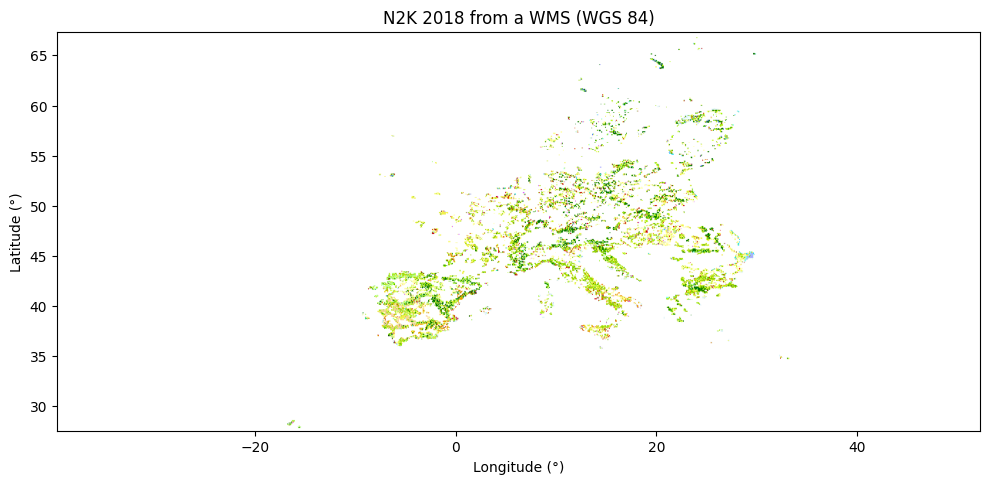

In [ ]:
# When we know the layers, we can request the map image
# This depends on the WMS service
# Lets try:
# (Note: you can play with other parameters, like styles, size, etc.)
response = wms.getmap(
    layers=[layer_name],
    styles=[""],
    srs="EPSG:4326",
    bbox=bbox,
    size=(1200, 800),
    format="image/png",
    transparent=False,
)
# The response is a bytes object, we need to convert it to an image
image = plt.imread(BytesIO(response.read()))


# And now, we can plot the image
# but, what is the right size?
# Same bbox as GetMap: x = longitude, y = latitude (degrees)
minx, miny, maxx, maxy = bbox
extent = (minx, maxx, miny, maxy)

fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(image, extent=extent, origin="upper", aspect="equal")
ax.set_title("N2K 2018 from a WMS (WGS 84)")
ax.set_xlabel("Longitude (°)")
ax.set_ylabel("Latitude (°)")
ax.ticklabel_format(style="plain", axis="both")
plt.tight_layout()
plt.show()


Focus bbox (EPSG:4326): (-5.5, 40.0, -3.0, 42.5)


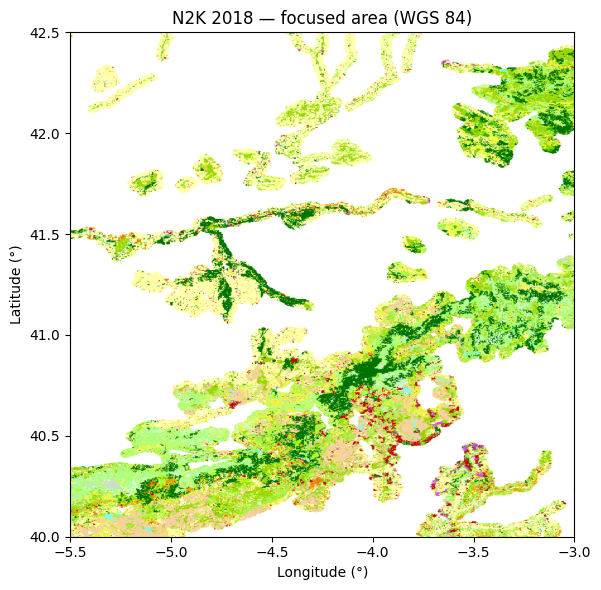

In [ ]:
# Lets focus on a specific area 
# (EPSG:4326: min_lon, min_lat, max_lon, max_lat).
# Values must overlap the layer extent printed above.

area_of_interest = (-5.5, 40.0, -3.0, 42.5) # you can change this for a specific area -> next activity

full_minx, full_miny, full_maxx, full_maxy = bbox
a0, a1, a2, a3 = area_of_interest
focus_minx = max(a0, full_minx)
focus_miny = max(a1, full_miny)
focus_maxx = min(a2, full_maxx)
focus_maxy = min(a3, full_maxy)

# and similar process to get, and plot the image
focus_bbox = (focus_minx, focus_miny, focus_maxx, focus_maxy)
print("Focus bbox (EPSG:4326):", focus_bbox)

response_focus = wms.getmap(
    layers=[layer_name],
    styles=[""],
    srs="EPSG:4326",
    bbox=focus_bbox,
    size=(1200, 800),
    format="image/png",
    transparent=False,
)
raster_focus = plt.imread(BytesIO(response_focus.read()))

fx0, fy0, fx1, fy1 = focus_bbox
extent_focus = (fx0, fx1, fy0, fy1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(raster_focus, extent=extent_focus, origin="upper", aspect="equal")
ax.set_title("N2K 2018 — focused area (WGS 84)")
ax.set_xlabel("Longitude (°)")
ax.set_ylabel("Latitude (°)")
ax.ticklabel_format(style="plain", axis="both")
plt.tight_layout()
plt.show()


## Activity 1. Can you focus on Balearic Islands?

In [ ]:
# Implement the activity 1 here

## Look: the image is a Numpy variable!!!!
If is a Numpy image you can use Numpy functions to operate 

In [6]:
type(image)

numpy.ndarray

In [7]:
# As the image is a Numpy variable, you can use the same indexing as a matrix.
# For example, to get the first row, you can do:
image[0, :, :]



array([[1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       ...,
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.]], shape=(1200, 3), dtype=float32)

In [ ]:
# Min/max values over the whole array (all rows, columns, and colour channels)
image.min(), image.max()


(np.float32(0.0), np.float32(1.0))

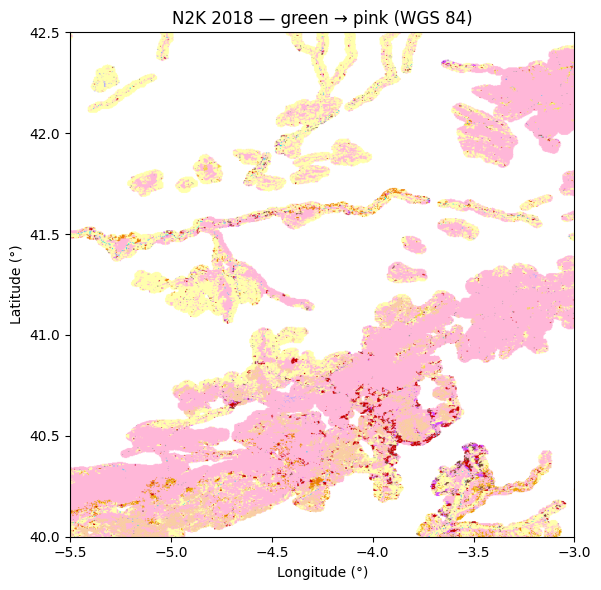

In [ ]:
# We can transform  green-dominant pixels to pink (RGB).
# We will use the focused raster, not the full-extent `image`.

displayed = raster_focus.copy() # good practice to avoid modifying the original

r = displayed[..., 0]
g = displayed[..., 1]
b = displayed[..., 2]

# Pixels that look "green" in RGB: G channel is highest and strong enough
green_mask = (g > r) & (g > b) & (g > 0.2) # the mask is a boolean array! "0,0,1,0,0..."

# Given the previous selection 
# We "Pink" the target (RGB in [0, 1]): high red and blue, moderate green
displayed[..., 0][green_mask] = 1.0
displayed[..., 1][green_mask] = 0.72
displayed[..., 2][green_mask] = 0.85
# Alpha channel (if present) is left unchanged

# and plotting the result
fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(displayed, extent=extent_focus, origin="upper", aspect="equal")
ax.set_title("N2K 2018 — green → pink (WGS 84)")
ax.set_xlabel("Longitude (°)")
ax.set_ylabel("Latitude (°)")
ax.ticklabel_format(style="plain", axis="both")
plt.tight_layout()
plt.show()


## Saving the map

When we do some tasks on images, we need to store the results...

- **Matplotlib** (`plt.imsave`): saves a NumPy array, for example `displayed` after processing, as a PNG.
- **OWSLib** (`wms.getmap`): the returned value is the HTTP response; call `.read()` once and write those **bytes** to a file to save exactly what the WMS sends before `imread`.


In [10]:
from pathlib import Path

out_dir = Path("data")

# 1) Matplotlib: save the already processed image (array -> PNG)
plt.imsave(out_dir / "n2k_focus_displayed.png", displayed)

# 2) OWSLib: save the raw WMS PNG (same request as the focused view)
_resp = wms.getmap(
    layers=[layer_name],
    styles=[""],
    srs="EPSG:4326",
    bbox=focus_bbox,
    size=(1200, 800),
    format="image/png",
    transparent=False,
)
png_bytes = _resp.read()
(out_dir / "n2k_focus_raw_wms.png").write_bytes(png_bytes)

print("Saved:", out_dir / "n2k_focus_displayed.png")
print("Saved:", out_dir / "n2k_focus_raw_wms.png")


Saved: data/n2k_focus_displayed.png
Saved: data/n2k_focus_raw_wms.png


## Rasterio: clipping with `mask`

[This is another library! Take a look in the web](https://rasterio.readthedocs.io/en/stable/)

A lot of possibilities playing with Numpy and Rasterio.



### Simpler option when you only need a **rectangle**


For a **rectangle inset** aligned with the image (same as the `box` above), the WMS image is sampled **uniformly** over `focus_bbox` in EPSG:4326, so you can **crop pixels with NumPy** — no extra library, no `MemoryFile`:

```python
rin = round(h * 0.15)
cin = round(w * 0.15)
crop_simple = raster_focus[rin : h - rin, cin : w - cin, :]
```

Use **Rasterio `mask`** when you need **non-rectangular** geometries, **reprojection**, or **exact** geodetic clipping — not just equal pixel margins.


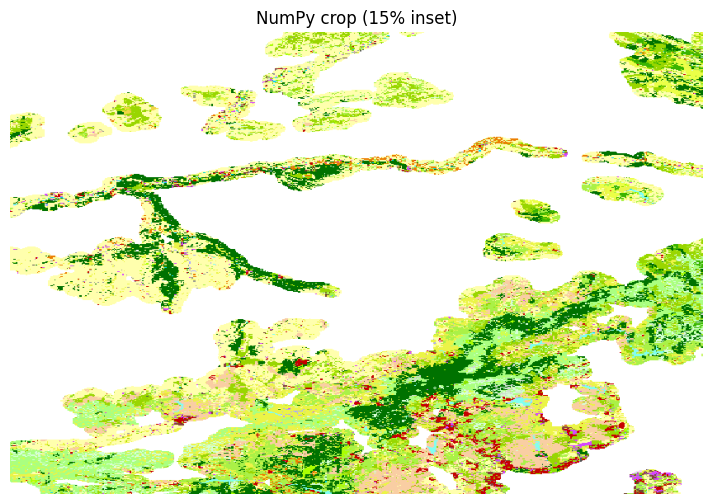

In [11]:
# Same 15% inset as the clip example above, in pixel space (no Rasterio)
h, w = raster_focus.shape[0], raster_focus.shape[1]
rin = round(h * 0.15)
cin = round(w * 0.15)
crop_simple = raster_focus[rin : h - rin, cin : w - cin, :]

fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(crop_simple)
ax.set_title("NumPy crop (15% inset)")
ax.axis("off")
plt.show()


## Simple classification for extracting features (pixels)

The WMS image is **RGB** rather than a single fixed 0-255 "band 1". To highlight areas with a **greener spectral response** (a vegetation proxy in this map), we use the **Excess Green** index:

`ExG = 2G - R - B` over `R,G,B` normalized to `[0,1]`.

- **Binary:** `np.where(ExG > threshold, 1, 0)`.
- **Multiple classes:** thresholds over `ExG`, for example 0, 0.06, 0.14, assigning 0...3.

The thresholds are indicative; adjust them to the contrast of the image.


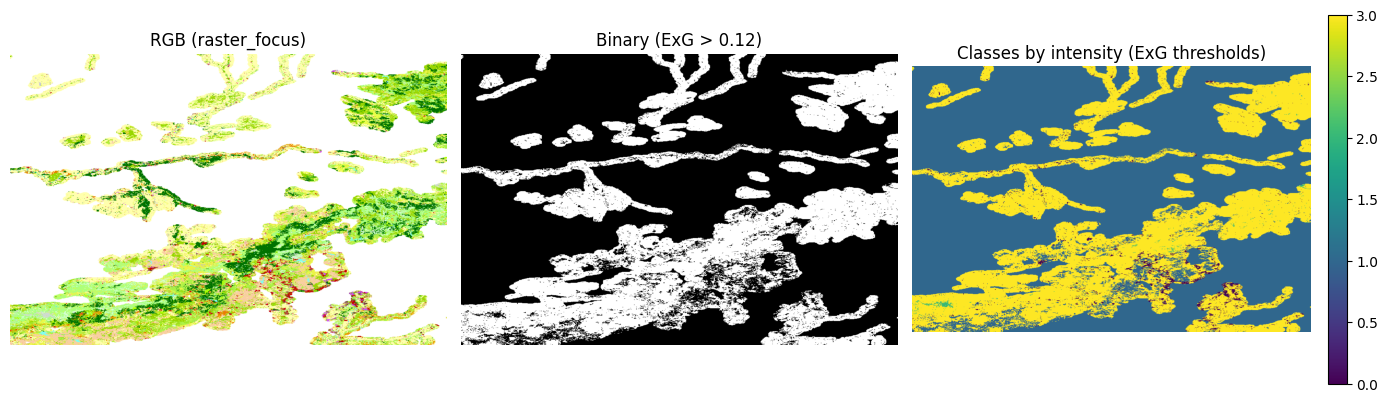

Class 1 pixels (binary): 330339 of 960000


In [12]:
import numpy as np

rgb = raster_focus[..., :3].astype(np.float32)
if rgb.max() > 1.0:
    rgb = rgb / 255.0

r, g, b = rgb[..., 0], rgb[..., 1], rgb[..., 2]
ex_green = 2 * g - r - b  # spectral feature per pixel (ExG)

# Binary classification: areas with high ExG
t_bin = 0.12
classified = np.where(ex_green > t_bin, 1, 0).astype(np.uint8)

# Four ExG intensity levels (classes 0-3)
classes_k = np.zeros_like(ex_green, dtype=np.uint8)
classes_k[ex_green >= 0.0] = 1
classes_k[ex_green >= 0.06] = 2
classes_k[ex_green >= 0.14] = 3

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(rgb)
axes[0].set_title("RGB (raster_focus)")
axes[0].axis("off")
axes[1].imshow(classified, cmap="Greys_r", vmin=0, vmax=1)
axes[1].set_title(f"Binary (ExG > {t_bin})")
axes[1].axis("off")
im = axes[2].imshow(classes_k, cmap="viridis", vmin=0, vmax=3)
axes[2].set_title("Classes by intensity (ExG thresholds)")
axes[2].axis("off")
plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

print("Class 1 pixels (binary):", int(classified.sum()), "of", classified.size)


### Save the classification as GeoTIFF

Use the same **`focus_bbox`** (EPSG:4326) and dimensions as `raster_focus`, with `rasterio.transform.from_bounds` as in the clipping section.

Three GeoTIFF files are written to `data/`: binary, multiclass, and the floating-point `ExG` band.


In [13]:
from pathlib import Path

import rasterio
from rasterio.transform import from_bounds

out_dir = Path("data")
out_dir.mkdir(parents=True, exist_ok=True)

height, width = classified.shape
minx, miny, maxx, maxy = focus_bbox
transform = from_bounds(minx, miny, maxx, maxy, width, height)

base_profile = {
    "driver": "GTiff",
    "height": height,
    "width": width,
    "count": 1,
    "crs": "EPSG:4326",
    "transform": transform,
    "compress": "deflate",
}

path_bin = out_dir / "n2k_focus_classified_binary.tif"
path_multi = out_dir / "n2k_focus_classes_multiclass.tif"
path_exg = out_dir / "n2k_focus_ex_green.tif"

with rasterio.open(path_bin, "w", dtype="uint8", **base_profile) as dst:
    dst.write(classified[np.newaxis, ...])

with rasterio.open(path_multi, "w", dtype="uint8", **base_profile) as dst:
    dst.write(classes_k[np.newaxis, ...])

with rasterio.open(path_exg, "w", dtype="float32", **base_profile) as dst:
    dst.write(ex_green.astype(np.float32)[np.newaxis, ...])

print("Written:", path_bin)
print("Written:", path_multi)
print("Written:", path_exg)


Written: data/n2k_focus_classified_binary.tif
Written: data/n2k_focus_classes_multiclass.tif
Written: data/n2k_focus_ex_green.tif


## Activity 2. "Greenness" (%) over an area, for example the Balearic Islands

**Goal:** estimate what fraction of the area of interest is classified as having a **high "green" response** according to the ExG index and a threshold, relative to the total analyzed area.

### Suggested approach

1. **Define the area of interest (AOI)**  
   - Simple option: a rectangular `area_of_interest` covering the Balearic Islands (lon/lat in EPSG:4326), as in the focused view.  

2. **Request the WMS image** for that `bbox` using the same layer and `srs=EPSG:4326`, then calculate **ExG** and the binary mask `classified` with the same logic as in the notebook.

3. **Define "greenness"** explicitly, for example `classified == 1` (ExG > `t_bin`) or classes >= 2 in `classes_k` if you want "medium-high greenness".

4. **Calculate the percentage**  
   - *Over the request rectangle (fast):*  
     `100 * classified.sum() / classified.size`  
     (assumes all raster pixels count equally; useful for comparing thresholds between runs).
   - *Over the island polygon (better):* mask with the polygon and use only pixels inside the AOI:  
     `100 * green_pixels_in_aoi / pixels_in_aoi`.

   - **Note: this is not real surface area.** In EPSG:4326, pixel size in meters varies with latitude. For real area estimates, reproject to a **metric** CRS and weight by **cell area** in m².


In [ ]:
# Implement the activity 2 here